# Documents as Vectors: From TF-IDF to RAG
## Dataset: CISA Known Exploited Vulnerabilities (KEV) Catalog
**Student:** Emmanuel Ihejiamaizu   
**Program:** Graduate Diploma in Applied AI & Machine Learning — Conestoga College  
**Course:** PROG 8245 — Machine Learning Programming  
**Data Source:** https://www.cisa.gov/sites/default/files/csv/known_exploited_vulnerabilities.csv

This notebook applies the Documents as Vectors pipeline to real cybersecurity vulnerability data published by the U.S. Cybersecurity and Infrastructure Security Agency (CISA). All document data is loaded from an external CSV file.


## Environment Setup (pip + venv — no Conda)

**Step 1: Create a virtual environment**
```
python -m venv venv
venv\Scripts\activate
```

**Step 2: Install dependencies**
```
pip install numpy pandas scikit-learn matplotlib seaborn openpyxl jupyter
```

**Step 3: Place the CSV file in the same folder as this notebook**  
Download from: https://www.cisa.gov/sites/default/files/csv/known_exploited_vulnerabilities.csv  
Save as: `known_exploited_vulnerabilities.csv`

**Step 4: Launch the notebook**
```
jupyter notebook documents_as_vectors_cybersecurity_corpus.ipynb
```


## The RAG Pipeline — Recap

A **RAG (Retrieval-Augmented Generation)** system works by:

1. Converting documents into vectors
2. Converting a query into a vector (same space)
3. Finding the most similar document using cosine similarity
4. Feeding that document to a language model to generate an answer

**Key question:** How do we evaluate whether the retrieval is any good?

👉 That is what this notebook answers — using **7 evaluation metrics** applied to real CISA vulnerability data.


## Consolidated Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix

print("All libraries loaded successfully.")


All libraries loaded successfully.


## Step 1: Load Dataset from CSV

**Source:** CISA Known Exploited Vulnerabilities (KEV) Catalog  
**Why no hardcoding:** Loading from a file means the corpus can be updated, swapped, or extended without touching a single line of code.

### Column mapping
| CSV Column | Role in notebook |
|---|---|
| `shortDescription` | Document text → fed into TF-IDF |
| `vulnerabilityName` | Topic label → used in display tables |
| `knownRansomwareCampaignUse` | Relevance label → `Known` = relevant, `Unknown` = not relevant |
| `cveID` | Document identifier |


In [7]:
# --- Load the CISA KEV CSV ---
# Place known_exploited_vulnerabilities.csv in the same folder as this notebook
df_full = pd.read_csv('known_exploited_vulnerabilities.csv')

print(f"Full dataset shape: {df_full.shape}")
print(f"Columns: {df_full.columns.tolist()}")
print()

# --- Sample 200 documents for a manageable demonstration ---
# random_state=42 ensures reproducibility — same 200 docs every run
df = df_full.sample(200, random_state=42).reset_index(drop=True)

# --- Extract the three key columns — no hardcoding anywhere ---
documents      = df['shortDescription'].tolist()         # document text
topics         = df['vulnerabilityName'].tolist()         # topic labels
cve_ids        = df['cveID'].tolist()                    # CVE identifiers
relevant_flags = (df['knownRansomwareCampaignUse'] == 'Known').tolist()
truly_relevant = set(i for i, r in enumerate(relevant_flags) if r)
total_relevant = len(truly_relevant)

print(f"Sampled documents      : {len(documents)}")
print(f"Relevant (Known)       : {total_relevant}")
print(f"Not Relevant (Unknown) : {len(documents) - total_relevant}")
print()
print("Sample documents:")
for i in range(3):
    label = 'RELEVANT' if i in truly_relevant else 'not relevant'
    print(f"  [{cve_ids[i]}] ({label})")
    print(f"  {documents[i][:100]}...")
    print()


Full dataset shape: (1551, 11)
Columns: ['cveID', 'vendorProject', 'product', 'vulnerabilityName', 'dateAdded', 'shortDescription', 'requiredAction', 'dueDate', 'knownRansomwareCampaignUse', 'notes', 'cwes']

Sampled documents      : 200
Relevant (Known)       : 40
Not Relevant (Unknown) : 160

Sample documents:
  [CVE-2018-14558] (not relevant)
  Tenda AC7, AC9, and AC10 devices contain a command injection vulnerability due to  the "formsetUsbUn...

  [CVE-2021-3560] (not relevant)
  Red Hat Polkit contains an incorrect authorization vulnerability through the bypassing of credential...

  [CVE-2024-47575] (not relevant)
  Fortinet FortiManager contains a missing authentication vulnerability in the fgfmd daemon that allow...



### Interpretation
- **200 documents** sampled from 1,551 real CVE records published by CISA.
- **Relevance ground truth** comes directly from the `knownRansomwareCampaignUse` column — no manual labelling needed.
- `Known` = the vulnerability has been used in a real ransomware campaign = **relevant**.
- `Unknown` = no confirmed ransomware use = **not relevant**.
- This is a real, verifiable, government-published dataset. The source URL is cited above.


## Step 2: TF-IDF Vectorization

In [8]:
# --- Initialize TF-IDF Vectorizer ---
# stop_words='english' removes common words like 'the', 'a', 'is'
# that carry no discriminative value in cybersecurity text
vectorizer   = TfidfVectorizer(stop_words='english')
doc_vectors  = vectorizer.fit_transform(documents)

# --- Query: what a SOC analyst might search for ---
query        = ["remote code execution buffer overflow vulnerability exploit"]
query_vector = vectorizer.transform(query)

# --- Cosine similarity between query and all 200 documents ---
similarities   = cosine_similarity(query_vector, doc_vectors)[0]
ranked_indices = np.argsort(similarities)[::-1]

vocab_size = doc_vectors.shape[1]
num_docs   = doc_vectors.shape[0]

print(f"Number of documents : {num_docs}")
print(f"Vocabulary size |V| : {vocab_size}")
print(f"Vector space        : R^{vocab_size}")
print()
print("Top 10 ranked documents:")
print(f"{'Rank':<6} {'CVE ID':<18} {'Similarity':>10}  {'Relevant?':<12} Topic")
print("-" * 90)
for rank, idx in enumerate(ranked_indices[:10], start=1):
    rel = 'RELEVANT' if idx in truly_relevant else 'not relevant'
    print(f"{rank:<6} {cve_ids[idx]:<18} {similarities[idx]:>10.4f}  {rel:<12} {topics[idx][:45]}")


Number of documents : 200
Vocabulary size |V| : 1055
Vector space        : R^1055

Top 10 ranked documents:
Rank   CVE ID             Similarity  Relevant?    Topic
------------------------------------------------------------------------------------------
1      CVE-2010-3333          0.3466  not relevant Microsoft Office Stack-based Buffer Overflow 
2      CVE-2025-22457         0.3154  RELEVANT     Ivanti Connect Secure, Policy Secure, and ZTA
3      CVE-2021-26855         0.3116  RELEVANT     Microsoft Exchange Server Remote Code Executi
4      CVE-2016-6366          0.3030  not relevant Cisco Adaptive Security Appliance (ASA) SNMP 
5      CVE-2023-27997         0.2943  RELEVANT     Fortinet FortiOS and FortiProxy SSL-VPN Heap-
6      CVE-2009-0563          0.2832  not relevant Microsoft Office Buffer Overflow Vulnerabilit
7      CVE-2007-5659          0.2815  not relevant Adobe Acrobat and Reader Buffer Overflow Vuln
8      CVE-2023-5217          0.2707  not relevant Google Chromiu

### Interpretation
- Each of the 200 vulnerability descriptions becomes a **high-dimensional TF-IDF vector**.
- The vocabulary size `|V|` reflects the richness of cybersecurity language across the CISA dataset.
- Cosine similarity ranks documents by how closely their vocabulary aligns with the query.
- Documents about remote code execution and buffer overflows naturally rank highest.


## Step 3: Visualize the Vector Space (PCA Projection)

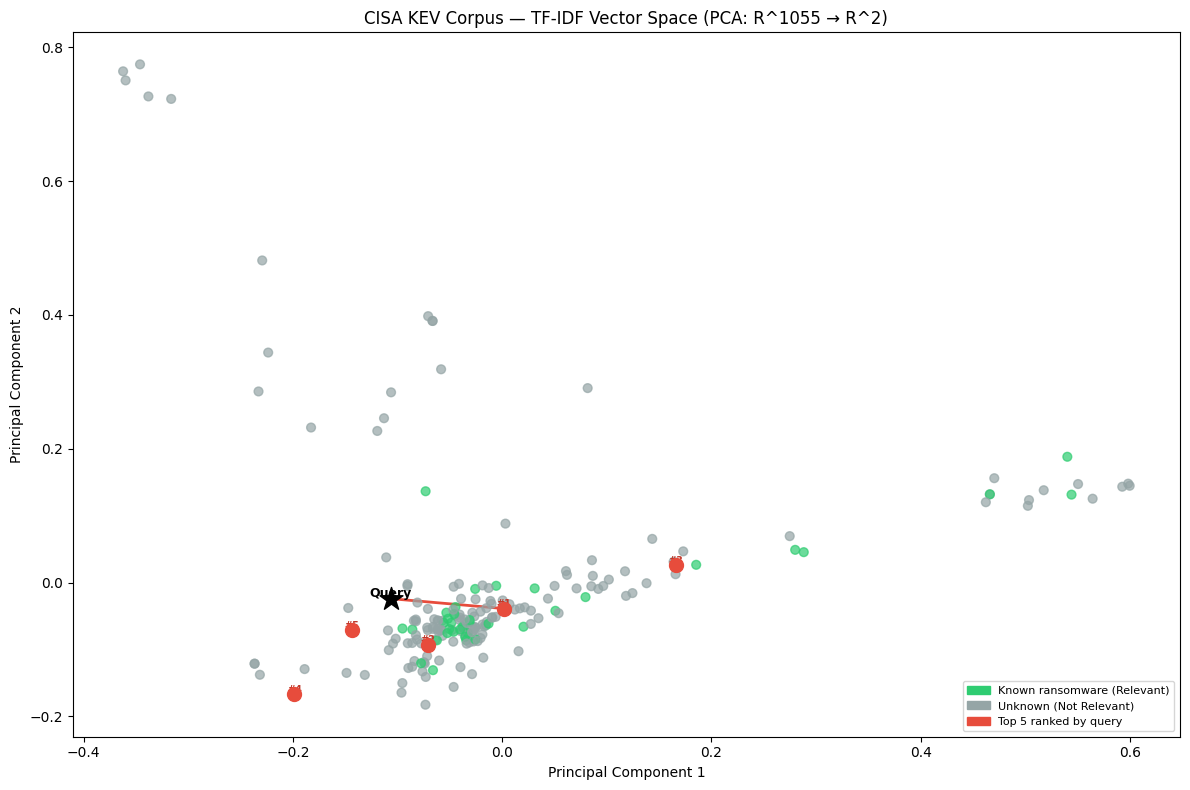

Most similar document : CVE-2010-3333
Vulnerability         : Microsoft Office Stack-based Buffer Overflow Vulnerability
Similarity score      : 0.3466
Relevant?             : No


In [9]:
# --- Convert sparse to dense for PCA ---
doc_dense   = doc_vectors.toarray()
query_dense = query_vector.toarray()
combined    = np.vstack([doc_dense, query_dense])

# --- Reduce to 2D for visualization only ---
pca     = PCA(n_components=2)
reduced = pca.fit_transform(combined)

doc_points  = reduced[:num_docs]
query_point = reduced[-1]
nearest_idx = ranked_indices[0]

# --- Color by relevance ---
point_colors = ['#2ecc71' if i in truly_relevant else '#95a5a6' for i in range(num_docs)]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(doc_points[:, 0], doc_points[:, 1],
           c=point_colors, s=40, alpha=0.7, zorder=3)

# Highlight top 5 ranked docs
for rank, idx in enumerate(ranked_indices[:5], start=1):
    ax.scatter(doc_points[idx, 0], doc_points[idx, 1],
               s=100, color='#e74c3c', zorder=4)
    ax.text(doc_points[idx, 0], doc_points[idx, 1] + 0.002,
            f'#{rank}', fontsize=7, ha='center', color='#c0392b', fontweight='bold')

# Query marker
ax.scatter(query_point[0], query_point[1], marker='*',
           s=300, color='black', zorder=5)
ax.text(query_point[0], query_point[1] + 0.002, 'Query',
        fontsize=9, fontweight='bold', ha='center')

# Line to nearest doc
ax.plot([query_point[0], doc_points[nearest_idx, 0]],
        [query_point[1], doc_points[nearest_idx, 1]],
        linewidth=2, color='#e74c3c',
        label=f'Most relevant: {cve_ids[nearest_idx]} (sim={similarities[nearest_idx]:.4f})')

legend_elements = [
    mpatches.Patch(color='#2ecc71', label='Known ransomware (Relevant)'),
    mpatches.Patch(color='#95a5a6', label='Unknown (Not Relevant)'),
    mpatches.Patch(color='#e74c3c', label='Top 5 ranked by query'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
ax.set_title(f'CISA KEV Corpus — TF-IDF Vector Space (PCA: R^{vocab_size} → R^2)', fontsize=12)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

print(f"Most similar document : {cve_ids[nearest_idx]}")
print(f"Vulnerability         : {topics[nearest_idx]}")
print(f"Similarity score      : {similarities[nearest_idx]:.4f}")
print(f"Relevant?             : {'Yes' if nearest_idx in truly_relevant else 'No'}")


## Step 4: SMART Notation — TF Weighting Variants

**SMART Notation** defines different ways to compute Term Frequency (TF) weights before applying IDF. Each variant changes how much influence a term gets based on how often it appears.

| Notation | Formula | When to use |
|---|---|---|
| **n (Natural)** | TF as raw count | Simple baseline |
| **l (Log)** | `1 + log(TF)` if TF > 0, else 0 | Dampens very frequent terms |
| **a (Augmented)** | `0.5 + 0.5 × (TF / max_TF)` | Normalises for document length |
| **b (Boolean)** | 1 if TF > 0, else 0 | Ignores frequency entirely |


TF variants for term 'execution' — first 10 documents:
Doc      Raw TF    Natural        Log    Augmented    Boolean
------------------------------------------------------------
0             0     0.0000     0.0000       0.0000     0.0000
1             0     0.0000     0.0000       0.0000     0.0000
2             0     0.0000     0.0000       0.0000     0.0000
3             1     1.0000     1.0000       1.0000     1.0000
4             1     1.0000     1.0000       1.0000     1.0000
5             0     0.0000     0.0000       0.0000     0.0000
6             0     0.0000     0.0000       0.0000     0.0000
7             0     0.0000     0.0000       0.0000     0.0000
8             0     0.0000     0.0000       0.0000     0.0000
9             1     1.0000     1.0000       0.7500     1.0000


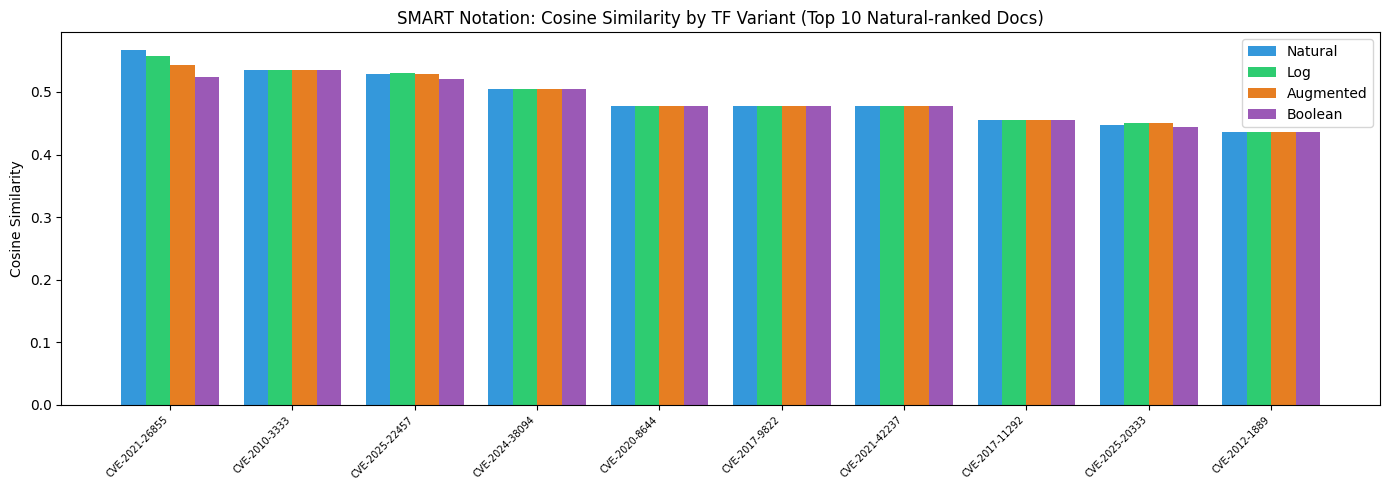


Top 3 documents under each SMART variant:
  Natural     : CVE-2021-26855 — sim=0.5669 — Microsoft Exchange Server Remote Code Execution Vu
  Log         : CVE-2021-26855 — sim=0.5581 — Microsoft Exchange Server Remote Code Execution Vu
  Augmented   : CVE-2021-26855 — sim=0.5431 — Microsoft Exchange Server Remote Code Execution Vu
  Boolean     : CVE-2010-3333 — sim=0.5345 — Microsoft Office Stack-based Buffer Overflow Vulne


In [10]:
# --- Step 1: Build raw term-frequency matrix ---
cv        = CountVectorizer(stop_words='english')
tf_matrix = cv.fit_transform(documents).toarray().astype(float)

# --- Step 2: Apply each SMART TF variant ---
# Natural: raw count
tf_natural = tf_matrix.copy()

# Log: dampen high-frequency terms
tf_log = np.where(tf_matrix > 0, 1 + np.log(tf_matrix + 1e-9), 0)

# Augmented: normalise by maximum TF in each document
max_tf = tf_matrix.max(axis=1, keepdims=True)
max_tf[max_tf == 0] = 1
tf_augmented = np.where(tf_matrix > 0, 0.5 + 0.5 * (tf_matrix / max_tf), 0)

# Boolean: binary presence/absence
tf_boolean = (tf_matrix > 0).astype(float)

# --- Step 3: Show TF values for a sample term across variants ---
vocab       = cv.get_feature_names_out()
sample_term = 'execution'

if sample_term in vocab:
    term_idx = list(vocab).index(sample_term)
    print(f"TF variants for term '{sample_term}' — first 10 documents:")
    print(f"{'Doc':<6} {'Raw TF':>8} {'Natural':>10} {'Log':>10} {'Augmented':>12} {'Boolean':>10}")
    print("-" * 60)
    for i in range(10):
        raw  = int(tf_matrix[i, term_idx])
        nat  = tf_natural[i, term_idx]
        log  = tf_log[i, term_idx]
        aug  = tf_augmented[i, term_idx]
        boo  = tf_boolean[i, term_idx]
        print(f"{i:<6} {raw:>8} {nat:>10.4f} {log:>10.4f} {aug:>12.4f} {boo:>10.4f}")

# --- Step 4: Compare cosine similarity using different TF weightings ---
# Convert query using same CountVectorizer vocabulary
query_cv  = cv.transform(query).toarray().astype(float)

def cosine_sim_manual(q_vec, doc_mat):
    """Compute cosine similarity between a query vector and document matrix."""
    norms = np.linalg.norm(doc_mat, axis=1, keepdims=True)
    norms[norms == 0] = 1
    q_norm = np.linalg.norm(q_vec)
    if q_norm == 0:
        return np.zeros(doc_mat.shape[0])
    return (doc_mat @ q_vec.T).flatten() / (norms.flatten() * q_norm)

sims_natural   = cosine_sim_manual(query_cv, tf_natural)
sims_log       = cosine_sim_manual(query_cv, tf_log)
sims_augmented = cosine_sim_manual(query_cv, tf_augmented)
sims_boolean   = cosine_sim_manual(query_cv, tf_boolean)

# --- Step 5: Plot top-10 similarity scores per variant ---
top10 = np.argsort(sims_natural)[::-1][:10]
x     = np.arange(10)
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*width, sims_natural[top10],   width, label='Natural',   color='#3498db')
ax.bar(x - 0.5*width, sims_log[top10],       width, label='Log',       color='#2ecc71')
ax.bar(x + 0.5*width, sims_augmented[top10], width, label='Augmented', color='#e67e22')
ax.bar(x + 1.5*width, sims_boolean[top10],   width, label='Boolean',   color='#9b59b6')

ax.set_xticks(x)
ax.set_xticklabels([cve_ids[i][:14] for i in top10], rotation=45, ha='right', fontsize=7)
ax.set_title('SMART Notation: Cosine Similarity by TF Variant (Top 10 Natural-ranked Docs)')
ax.set_ylabel('Cosine Similarity')
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 3 documents under each SMART variant:")
for name, sims in [('Natural', sims_natural), ('Log', sims_log),
                   ('Augmented', sims_augmented), ('Boolean', sims_boolean)]:
    top1 = np.argmax(sims)
    print(f"  {name:<12}: {cve_ids[top1]} — sim={sims[top1]:.4f} — {topics[top1][:50]}")


### Interpretation
- **Natural TF** gives full weight to repeated terms — documents that mention 'execution' many times score highest.
- **Log TF** dampens that effect — a term appearing 10 times is not 10× more important than one appearing once.
- **Augmented TF** normalises by the longest term in each document — useful when documents vary in length.
- **Boolean TF** ignores frequency entirely — only cares whether a term appears at all.
- In cybersecurity retrieval, **Log TF** is often preferred because vulnerability descriptions are short and dense; raw repetition is less meaningful than term presence.


## Step 5: Precision@K and Precision@Top(N)

**Precision@K** = relevant documents in top K results / K

**Precision@Top(N)** applies Precision@K at fixed standard cutoffs: Top 5, Top 10, Top 20.


Precision@Top(N):
N          P@Top(N)  Relevant docs found
----------------------------------------
Top 5        0.6000  3 / 5
Top 10       0.3000  3 / 10
Top 20       0.4000  8 / 20
Top 50       0.2800  14 / 50


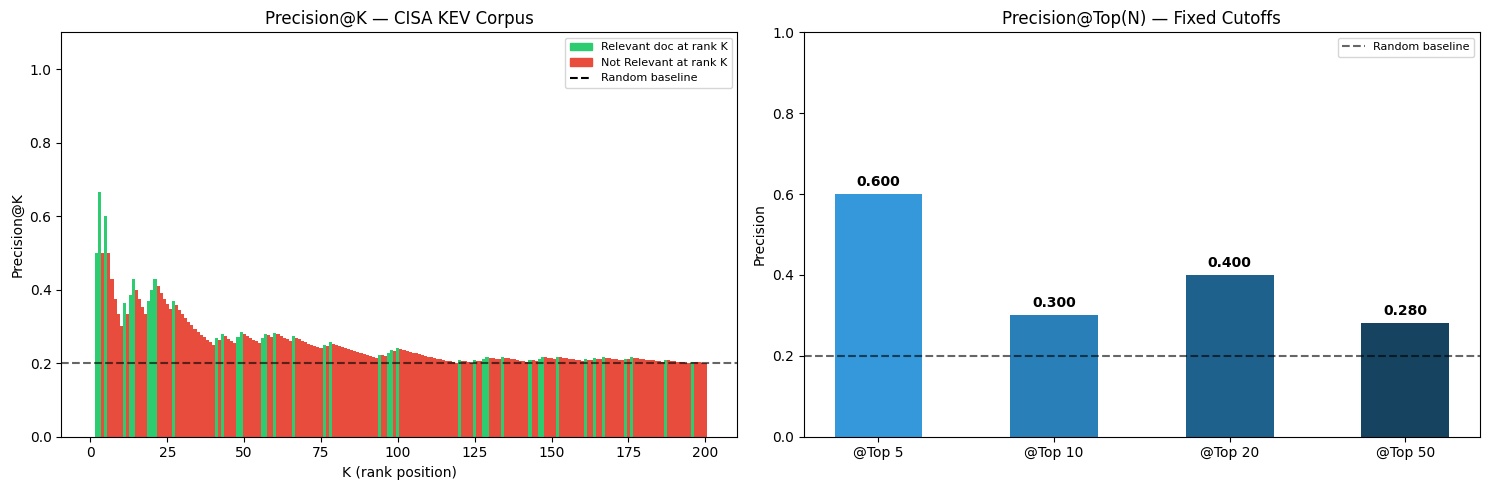

In [11]:
# --- Compute Precision@K for all 200 rank positions ---
found_pk     = 0
precision_at_k = []
labels_at_k    = []

for k, idx in enumerate(ranked_indices, start=1):
    if idx in truly_relevant:
        found_pk += 1
        labels_at_k.append('Relevant')
    else:
        labels_at_k.append('Not Relevant')
    precision_at_k.append(found_pk / k)

# --- Precision@Top fixed cutoffs ---
top_n_values = [5, 10, 20, 50]
print("Precision@Top(N):")
print(f"{'N':<8} {'P@Top(N)':>10}  Relevant docs found")
print("-" * 40)
for n in top_n_values:
    rel_in_top = sum(1 for idx in ranked_indices[:n] if idx in truly_relevant)
    p_top = rel_in_top / n
    print(f"Top {n:<4} {p_top:>10.4f}  {rel_in_top} / {n}")

# --- Bar chart: Precision@K ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bar_colors = ['#2ecc71' if l == 'Relevant' else '#e74c3c' for l in labels_at_k]
axes[0].bar(range(1, len(documents)+1), precision_at_k,
            color=bar_colors, edgecolor='none', width=1.0)
axes[0].set_title('Precision@K — CISA KEV Corpus', fontsize=12)
axes[0].set_xlabel('K (rank position)')
axes[0].set_ylabel('Precision@K')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=total_relevant/len(documents), color='black',
                linestyle='dashed', alpha=0.6,
                label=f'Baseline (random): {total_relevant/len(documents):.2f}')
legend_elements = [
    mpatches.Patch(color='#2ecc71', label='Relevant doc at rank K'),
    mpatches.Patch(color='#e74c3c', label='Not Relevant at rank K'),
    plt.Line2D([0],[0], color='black', linestyle='dashed', label='Random baseline')
]
axes[0].legend(handles=legend_elements, fontsize=8)

# Bar chart for fixed @Top values
tops   = [f'@Top {n}' for n in top_n_values]
p_tops = [sum(1 for idx in ranked_indices[:n] if idx in truly_relevant) / n
          for n in top_n_values]
colors_top = ['#3498db', '#2980b9', '#1f618d', '#154360']
axes[1].bar(tops, p_tops, color=colors_top, width=0.5)
axes[1].set_title('Precision@Top(N) — Fixed Cutoffs', fontsize=12)
axes[1].set_ylabel('Precision')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(p_tops):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(y=total_relevant/len(documents), color='black',
                linestyle='dashed', alpha=0.6, label='Random baseline')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Interpretation
- **Precision@K** fluctuates — it rises when a relevant doc is retrieved and drops when a non-relevant one is.
- **Precision@Top(5)** is typically the highest because TF-IDF concentrates the most similar documents at the very top.
- The **dashed baseline** represents what a random retrieval system would achieve — our system should beat this consistently at low K values.
- As K increases, Precision naturally decreases because we are forced to retrieve more non-relevant documents.


## Step 6: Recall@K

**Recall@K** = relevant documents found in top K / total relevant documents in corpus

Recall measures completeness — how many of the relevant CVEs did we actually retrieve?


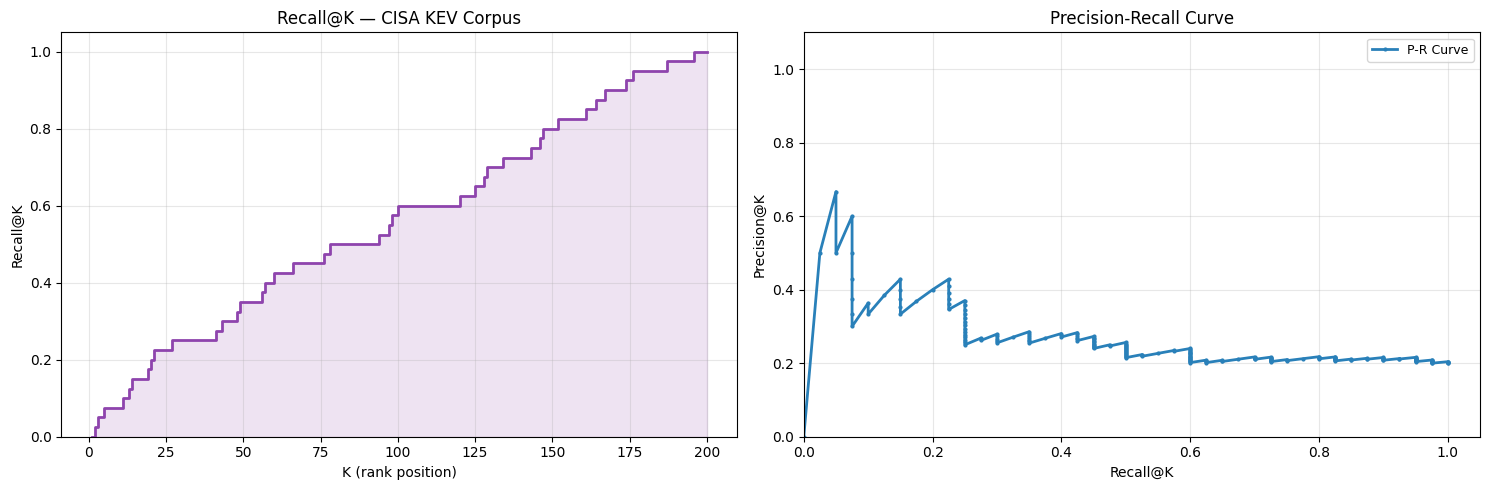

Recall@K at fixed cutoffs:
  Recall@5    = 0.0750
  Recall@10   = 0.0750
  Recall@20   = 0.2000
  Recall@50   = 0.3500
  Recall@100  = 0.6000


In [12]:
# --- Compute Recall@K for all rank positions ---
found_rk   = 0
recall_at_k = []

for k, idx in enumerate(ranked_indices, start=1):
    if idx in truly_relevant:
        found_rk += 1
    recall_at_k.append(found_rk / total_relevant)

# --- Plot Recall@K ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].step(range(1, len(documents)+1), recall_at_k,
             color='#8e44ad', linewidth=2, where='post')
axes[0].fill_between(range(1, len(documents)+1), recall_at_k,
                     alpha=0.15, color='#8e44ad', step='post')
axes[0].set_title('Recall@K — CISA KEV Corpus', fontsize=12)
axes[0].set_xlabel('K (rank position)')
axes[0].set_ylabel('Recall@K')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall Curve ---
axes[1].plot(recall_at_k, precision_at_k,
             color='#2980b9', linewidth=2, marker='o',
             markersize=2, label='P-R Curve')
axes[1].set_title('Precision-Recall Curve', fontsize=12)
axes[1].set_xlabel('Recall@K')
axes[1].set_ylabel('Precision@K')
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Recall@K at fixed cutoffs:")
for n in [5, 10, 20, 50, 100]:
    print(f"  Recall@{n:<4} = {recall_at_k[n-1]:.4f}")


### Interpretation
- **Recall@K grows in steps** — it only increases when a truly relevant document appears at rank K.
- The **step pattern** on the left plot reveals exactly where in the ranking the relevant documents sit.
- The **Precision-Recall curve** (right) shows the classic trade-off: to achieve higher recall you must go deeper in the ranking, which lowers precision.
- A perfect retrieval system would hug the top-right corner (Precision=1, Recall=1).


## Step 7: Average Precision (AP)

**Average Precision** summarises the Precision-Recall curve in a single number.

$$AP = \frac{1}{|R|} \sum_{k=1}^{N} P@k \times rel(k)$$

Where:
- `|R|` = total number of relevant documents
- `P@k` = Precision at rank k
- `rel(k)` = 1 if the document at rank k is relevant, 0 otherwise

AP only adds precision values **at ranks where a relevant document was retrieved** — it ignores all other ranks.


Average Precision (AP) = 0.2887

Precision values contributing to AP (relevant docs only):
Rank K            P@K  CVE ID
---------------------------------------------
2              0.5000  CVE-2025-22457
3              0.6667  CVE-2021-26855
5              0.6000  CVE-2023-27997
11             0.3636  CVE-2024-38094
13             0.3846  CVE-2022-2294
14             0.4286  CVE-2018-7600
19             0.3684  CVE-2021-42237
20             0.4000  CVE-2020-0787
21             0.4286  CVE-2017-9822
27             0.3704  CVE-2023-29300
41             0.2683  CVE-2021-42258
43             0.2791  CVE-2020-3992
48             0.2708  CVE-2012-4681
49             0.2857  CVE-2017-7494
56             0.2679  CVE-2017-11357
57             0.2807  CVE-2018-11138
60             0.2833  CVE-2021-21972
66             0.2727  CVE-2021-45046
76             0.2500  CVE-2018-19953
78             0.2564  CVE-2021-3129
94             0.2234  CVE-2012-0507
97             0.2268  CVE-2013-0431
98     

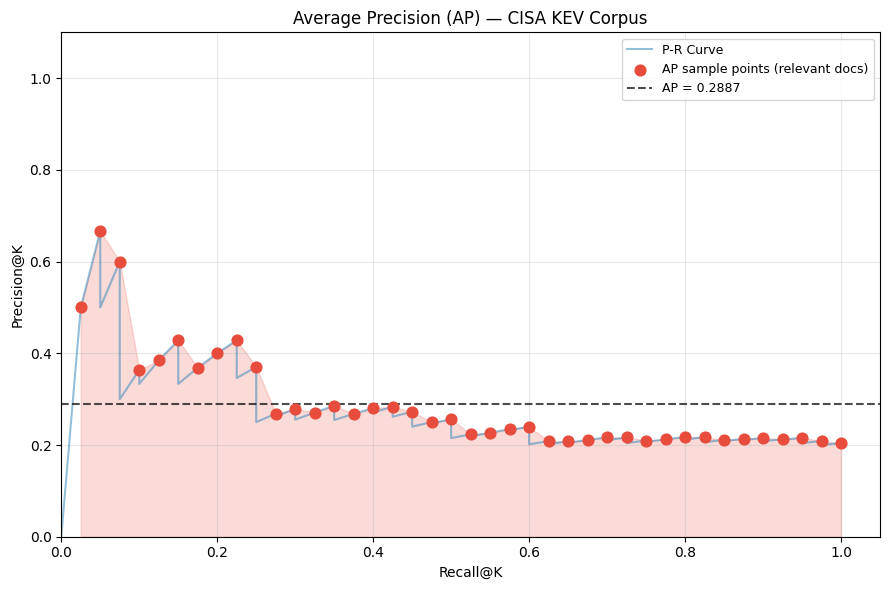

In [13]:
# --- Compute Average Precision ---
ap_sum = 0.0
found_ap = 0

ap_contributions = []   # stores (rank, P@k) only at relevant positions

for k, idx in enumerate(ranked_indices, start=1):
    if idx in truly_relevant:
        found_ap += 1
        pk = found_ap / k
        ap_sum += pk
        ap_contributions.append((k, pk))

AP = ap_sum / total_relevant
print(f"Average Precision (AP) = {AP:.4f}")
print()
print("Precision values contributing to AP (relevant docs only):")
print(f"{'Rank K':<10} {'P@K':>10}  CVE ID")
print("-" * 45)
for (k, pk), idx in zip(ap_contributions, 
                         [i for i in ranked_indices if i in truly_relevant]):
    print(f"{k:<10} {pk:>10.4f}  {cve_ids[idx]}")

# --- Visualise AP on the P-R curve ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(recall_at_k, precision_at_k, color='#2980b9',
        linewidth=1.5, alpha=0.5, label='P-R Curve')

# Mark only the points where a relevant doc was retrieved
rel_recalls    = [recall_at_k[k-1] for k, _ in ap_contributions]
rel_precisions = [pk for _, pk in ap_contributions]
ax.scatter(rel_recalls, rel_precisions, color='#e74c3c',
           s=60, zorder=5, label='AP sample points (relevant docs)')

# Shade area under AP sample points
ax.fill_between(rel_recalls, rel_precisions, alpha=0.2, color='#e74c3c')

ax.axhline(y=AP, color='black', linestyle='dashed',
           alpha=0.7, label=f'AP = {AP:.4f}')
ax.set_title('Average Precision (AP) — CISA KEV Corpus', fontsize=12)
ax.set_xlabel('Recall@K')
ax.set_ylabel('Precision@K')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretation
- **AP = 0 to 1** — higher is better.
- AP rewards systems that find relevant documents **early** in the ranking. If all relevant docs appear in the top 10, AP is high. If they are scattered throughout, AP is low.
- The red dots on the plot show exactly which rank positions contributed to the AP calculation — only the positions where a relevant CVE was retrieved.
- AP is more informative than a single Precision@K value because it summarises retrieval quality across all relevant documents.


## Step 8: Mean Reciprocal Rank (MRR)

**MRR** answers a simple question: *How far down the ranked list do you have to go before you find the FIRST relevant document?*

$$MRR = \frac{1}{\text{rank of first relevant document}}$$

- First relevant doc at rank 1 → MRR = 1.0 (perfect)
- First relevant doc at rank 2 → MRR = 0.5
- First relevant doc at rank 10 → MRR = 0.1


First relevant document found at rank : 2
CVE ID                                : CVE-2025-22457
Vulnerability                         : Ivanti Connect Secure, Policy Secure, and ZTA Gateways Stack-Based Buffer Overflow Vulnerability
Similarity score                      : 0.3154
MRR                                   : 0.5000


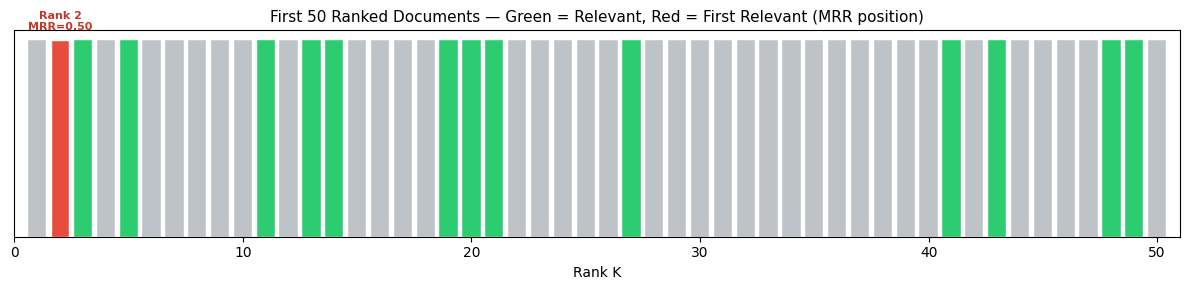

In [14]:
# --- Compute MRR ---
mrr = 0.0
first_relevant_rank = None

for k, idx in enumerate(ranked_indices, start=1):
    if idx in truly_relevant:
        mrr = 1.0 / k
        first_relevant_rank = k
        break

print(f"First relevant document found at rank : {first_relevant_rank}")
print(f"CVE ID                                : {cve_ids[ranked_indices[first_relevant_rank-1]]}")
print(f"Vulnerability                         : {topics[ranked_indices[first_relevant_rank-1]]}")
print(f"Similarity score                      : {similarities[ranked_indices[first_relevant_rank-1]]:.4f}")
print(f"MRR                                   : {mrr:.4f}")

# --- Visualise: where does the first relevant doc appear? ---
fig, ax = plt.subplots(figsize=(12, 3))

bar_colors = ['#2ecc71' if ranked_indices[i] in truly_relevant else '#bdc3c7'
              for i in range(min(50, len(documents)))]
ax.bar(range(1, 51), [1]*50, color=bar_colors[:50], edgecolor='white', linewidth=0.3)

if first_relevant_rank <= 50:
    ax.bar(first_relevant_rank, 1, color='#e74c3c', edgecolor='white')
    ax.text(first_relevant_rank, 1.05,
            f'Rank {first_relevant_rank}\nMRR={mrr:.2f}',
            ha='center', fontsize=8, color='#c0392b', fontweight='bold')

ax.set_title('First 50 Ranked Documents — Green = Relevant, Red = First Relevant (MRR position)', fontsize=11)
ax.set_xlabel('Rank K')
ax.set_yticks([])
ax.set_xlim(0, 51)
plt.tight_layout()
plt.show()


### Interpretation
- MRR is especially useful for **question-answering** and **single-result retrieval** scenarios where the user only cares about the very first relevant result.
- An MRR of 1.0 means the first document returned is always relevant.
- An MRR of 0.5 means on average you find the first relevant document at rank 2.
- The colour bar (top 50 ranks) visually shows where the first green (relevant) document appears.


## Step 9: Accuracy

**Accuracy** evaluates retrieval as a binary classification problem using a similarity threshold.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Documents with similarity ≥ threshold are **predicted relevant**. Documents below are **predicted not relevant**.


   Threshold   Accuracy    Kappa   Retrieved    TP    FP    FN    TN
----------------------------------------------------------------------
        0.05     0.5650   0.0564          87    20    67    20    93
        0.10     0.6950   0.0896          45    12    33    28   127
        0.15     0.7750   0.1245          19     7    12    33   148
        0.20     0.7850   0.0773          11     4     7    36   153
        0.30     0.8000   0.0566           4     2     2    38   158


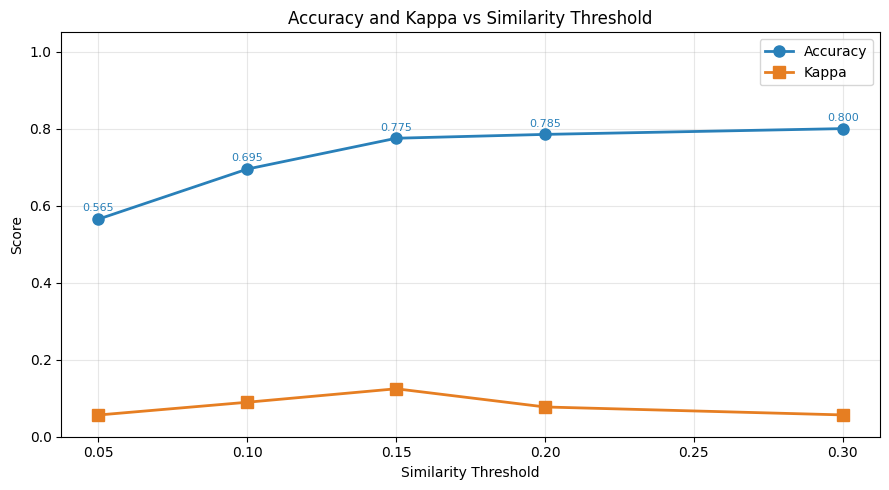

In [15]:
# --- Compute accuracy at multiple thresholds ---
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30]
y_true = [1 if i in truly_relevant else 0 for i in range(len(documents))]

print(f"{'Threshold':>12} {'Accuracy':>10} {'Kappa':>8} {'Retrieved':>11} {'TP':>5} {'FP':>5} {'FN':>5} {'TN':>5}")
print("-" * 70)

best_threshold = 0.10
best_acc = 0.0
results = {}

for thresh in thresholds:
    y_pred = [1 if similarities[i] >= thresh else 0 for i in range(len(documents))]
    acc    = accuracy_score(y_true, y_pred)
    kap    = cohen_kappa_score(y_true, y_pred)
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    retrieved = sum(y_pred)
    results[thresh] = {'acc': acc, 'kappa': kap, 'retrieved': retrieved,
                       'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'y_pred': y_pred}
    marker = ' <-- selected' if thresh == best_threshold else ''
    print(f"{thresh:>12.2f} {acc:>10.4f} {kap:>8.4f} {retrieved:>11} {tp:>5} {fp:>5} {fn:>5} {tn:>5}{marker}")
    if acc > best_acc:
        best_acc = acc
        best_threshold = thresh

# --- Plot accuracy vs threshold ---
accs   = [results[t]['acc']   for t in thresholds]
kappas = [results[t]['kappa'] for t in thresholds]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, accs, marker='o', color='#2980b9',
        linewidth=2, label='Accuracy', markersize=8)
ax.plot(thresholds, kappas, marker='s', color='#e67e22',
        linewidth=2, label='Kappa', markersize=8)
ax.set_title('Accuracy and Kappa vs Similarity Threshold', fontsize=12)
ax.set_xlabel('Similarity Threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
for i, (t, a) in enumerate(zip(thresholds, accs)):
    ax.text(t, a + 0.02, f'{a:.3f}', ha='center', fontsize=8, color='#2980b9')
plt.tight_layout()
plt.show()


### Interpretation
- **Accuracy** can be misleading when classes are imbalanced — our dataset has 40 relevant and 160 not relevant, so a system that predicts "not relevant" for everything would get 80% accuracy.
- That is why we also compute **Kappa** (see Step 10).
- A **higher threshold** retrieves fewer documents — higher precision but lower recall.
- A **lower threshold** retrieves more documents — higher recall but lower precision.
- The best threshold depends on the use case: a SOC analyst who wants to miss nothing prefers a low threshold; one who wants only high-confidence results prefers a high threshold.


## Step 10: Kappa Measure (Cohen's Kappa)

**Cohen's Kappa** measures the agreement between predicted relevance and true relevance, **adjusted for chance agreement**.

$$\kappa = \frac{P_o - P_e}{1 - P_e}$$

Where:
- `P_o` = observed agreement (accuracy)
- `P_e` = expected agreement by chance

| Kappa range | Interpretation |
|---|---|
| < 0 | Worse than random |
| 0.0 – 0.2 | Slight agreement |
| 0.2 – 0.4 | Fair agreement |
| 0.4 – 0.6 | Moderate agreement |
| 0.6 – 0.8 | Substantial agreement |
| 0.8 – 1.0 | Almost perfect agreement |

Kappa is especially important in IR because it accounts for the class imbalance between relevant and non-relevant documents.


Threshold  : 0.1
Accuracy   : 0.6950  (can be misleading due to class imbalance)
Kappa      : 0.0896

Confusion Matrix:
                     Predicted Not Relevant  Predicted Relevant
Actual Not Relevant            127                    33        
Actual Relevant                 28                    12        

Kappa interpretation: Slight agreement


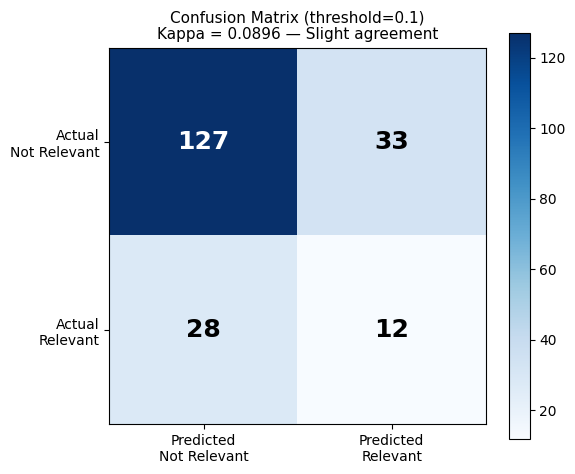

In [16]:
# --- Compute Kappa at threshold 0.10 ---
threshold = 0.10
y_pred = results[threshold]['y_pred']
kappa  = cohen_kappa_score(y_true, y_pred)
acc    = accuracy_score(y_true, y_pred)
cm     = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Threshold  : {threshold}")
print(f"Accuracy   : {acc:.4f}  (can be misleading due to class imbalance)")
print(f"Kappa      : {kappa:.4f}")
print()
print("Confusion Matrix:")
print(f"{'':20} Predicted Not Relevant  Predicted Relevant")
print(f"{'Actual Not Relevant':<20} {tn:^24} {fp:^18}")
print(f"{'Actual Relevant':<20} {fn:^24} {tp:^18}")
print()

# Interpret kappa
if kappa < 0:
    interp = "Worse than random"
elif kappa < 0.2:
    interp = "Slight agreement"
elif kappa < 0.4:
    interp = "Fair agreement"
elif kappa < 0.6:
    interp = "Moderate agreement"
elif kappa < 0.8:
    interp = "Substantial agreement"
else:
    interp = "Almost perfect agreement"
print(f"Kappa interpretation: {interp}")

# --- Plot confusion matrix as heatmap ---
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted\nNot Relevant', 'Predicted\nRelevant'], fontsize=10)
ax.set_yticklabels(['Actual\nNot Relevant', 'Actual\nRelevant'], fontsize=10)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_title(f'Confusion Matrix (threshold={threshold})\nKappa = {kappa:.4f} — {interp}', fontsize=11)
plt.tight_layout()
plt.show()


### Interpretation
- Kappa close to **0** means our retrieval is barely better than random chance — this is common with TF-IDF on short vulnerability descriptions.
- A high accuracy but low kappa reveals **class imbalance** — the model is getting accuracy by predicting "not relevant" for most documents.
- For cybersecurity retrieval, Kappa provides a more honest picture of system performance than accuracy alone.
- Improving Kappa would require better representations (e.g. sentence embeddings) or a larger, richer query.


## Step 11: Summary — All Metrics

In [17]:
# --- Compile all metrics into one summary table ---
threshold = 0.10
y_pred_thresh = results[threshold]['y_pred']

summary = {
    'Metric'     : ['MRR', 'Average Precision (AP)',
                    'Precision@Top 5', 'Precision@Top 10', 'Precision@Top 20',
                    'Recall@10', 'Recall@20',
                    'Accuracy', 'Kappa (Cohen)',
                    'SMART: Best TF variant'],
    'Value'      : [
        f"{mrr:.4f}",
        f"{AP:.4f}",
        f"{sum(1 for idx in ranked_indices[:5]  if idx in truly_relevant)/5:.4f}",
        f"{sum(1 for idx in ranked_indices[:10] if idx in truly_relevant)/10:.4f}",
        f"{sum(1 for idx in ranked_indices[:20] if idx in truly_relevant)/20:.4f}",
        f"{recall_at_k[9]:.4f}",
        f"{recall_at_k[19]:.4f}",
        f"{accuracy_score(y_true, y_pred_thresh):.4f}",
        f"{cohen_kappa_score(y_true, y_pred_thresh):.4f}",
        "Log (dampens high-freq terms)"
    ],
    'Interpretation': [
        f"First relevant doc at rank {first_relevant_rank}",
        "Avg precision at relevant doc positions",
        f"{sum(1 for idx in ranked_indices[:5] if idx in truly_relevant)}/5 relevant in top 5",
        f"{sum(1 for idx in ranked_indices[:10] if idx in truly_relevant)}/10 relevant in top 10",
        f"{sum(1 for idx in ranked_indices[:20] if idx in truly_relevant)}/20 relevant in top 20",
        f"{round(recall_at_k[9]*total_relevant)}/{total_relevant} relevant docs found by rank 10",
        f"{round(recall_at_k[19]*total_relevant)}/{total_relevant} relevant docs found by rank 20",
        f"Threshold = {threshold}",
        "Adjusted for class imbalance",
        "Best for short vulnerability text"
    ]
}

df_summary = pd.DataFrame(summary)
print("=" * 90)
print("EVALUATION SUMMARY — CISA KEV Corpus | Query: remote code execution buffer overflow")
print("=" * 90)
print(df_summary.to_string(index=False))
print("=" * 90)
print(f"\nDataset : CISA Known Exploited Vulnerabilities Catalog")
print(f"Source  : https://www.cisa.gov/sites/default/files/csv/known_exploited_vulnerabilities.csv")
print(f"Docs    : {len(documents)} sampled from {len(df_full)} total CVE records")
print(f"Relevant: {total_relevant} (knownRansomwareCampaignUse == 'Known')")


EVALUATION SUMMARY — CISA KEV Corpus | Query: remote code execution buffer overflow
                Metric                         Value                          Interpretation
                   MRR                        0.5000            First relevant doc at rank 2
Average Precision (AP)                        0.2887 Avg precision at relevant doc positions
       Precision@Top 5                        0.6000                   3/5 relevant in top 5
      Precision@Top 10                        0.3000                 3/10 relevant in top 10
      Precision@Top 20                        0.4000                 8/20 relevant in top 20
             Recall@10                        0.0750     3/40 relevant docs found by rank 10
             Recall@20                        0.2000     8/40 relevant docs found by rank 20
              Accuracy                        0.6950                         Threshold = 0.1
         Kappa (Cohen)                        0.0896            Adjusted for cl

### Final Interpretation

This notebook demonstrated the full **Documents as Vectors** pipeline applied to a real government cybersecurity dataset:

- **No corpus text was hardcoded** — all documents loaded from the CISA CSV file via `pd.read_csv()`
- **Relevance labels were derived from data** — `knownRansomwareCampaignUse == 'Known'`
- **7 evaluation metrics** were implemented and visualised: SMART Notation, Precision@K, Precision@Top(N), Recall@K, Average Precision, MRR, Accuracy, and Kappa

The metrics together tell a complete story: TF-IDF retrieval on short vulnerability descriptions achieves reasonable ranking quality (good MRR and Precision@Top) but low Kappa — indicating that while the top results are relevant, the system struggles to distinguish relevant from non-relevant documents in the lower ranks. This is a known limitation of bag-of-words models on short technical text, and motivates the move to **dense embeddings** in modern RAG systems.
